In [957]:
from build.models.main import *
from build import Genome
from build.util.datetime import eta, clock

from numpy import ndarray as CPUArray

import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
# import matplotlib.
import numpy as np

In [958]:
torch.set_printoptions(threshold=10)

In [959]:
device = 'cuda'
dtype  = torch.float64

In [960]:
genomes = {key: Genome(key) for key in range(1, 2)}

In [1066]:
batch_size  = 8
seq_len     = 32
input_dims  = 1
output_dims = 1
embedding   = 32
heads       = 2
layers      = 1
differential = False
bias        = False

In [1027]:
records = 10

In [1028]:
upper   = 1000
divider = upper + seq_len

In [1029]:
def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
    source = torch.stack([
        torch.stack([
            torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
        ]) for _ in range(records)
    ])
    if inv:
        source = source.mT
    inp = source * 2
    s = inp.shape[-2]
    # out = inp.clone()[..., s-1:s, :] + 1
    out = (source + 1) ** 1.5
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider, \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

In [1030]:
train_inp, train_out = create(len(genomes), 0, upper, records, seq_len, output_dims, True)
eval_inp, eval_out   = create(len(genomes), 0, upper, records, seq_len, output_dims, True)

In [1031]:
train_inp.shape, train_out.shape

(torch.Size([1, 10, 32, 1]), torch.Size([1, 10, 32, 1]))

In [1032]:
train_inp.mT

tensor([[[[0.1047, 0.1066, 0.1085,  ..., 0.1609, 0.1628, 0.1647]],

         [[1.1667, 1.1686, 1.1705,  ..., 1.2229, 1.2248, 1.2267]],

         [[0.6512, 0.6531, 0.6550,  ..., 0.7074, 0.7093, 0.7112]],

         ...,

         [[0.3198, 0.3217, 0.3236,  ..., 0.3760, 0.3779, 0.3798]],

         [[1.8566, 1.8585, 1.8605,  ..., 1.9128, 1.9147, 1.9167]],

         [[1.2016, 1.2035, 1.2054,  ..., 1.2578, 1.2597, 1.2616]]]],
       device='cuda:0', dtype=torch.float64)

In [1033]:
train_out.mT

tensor([[[[ 0.3952,  0.4061,  0.4170,  ...,  0.7460,  0.7594,  0.7728]],

         [[14.3482, 14.3839, 14.4196,  ..., 15.3956, 15.4321, 15.4687]],

         [[ 5.9947,  6.0214,  6.0481,  ...,  6.7849,  6.8127,  6.8406]],

         ...,

         [[ 2.0724,  2.0912,  2.1100,  ...,  2.6386,  2.6589,  2.6793]],

         [[28.7772, 28.8222, 28.8672,  ..., 30.0923, 30.1380, 30.1837]],

         [[14.9954, 15.0316, 15.0679,  ..., 16.0580, 16.0950, 16.1321]]]],
       device='cuda:0', dtype=torch.float64)

In [1034]:
# test_inp = torch.randn(len(genomes), records, seq_len, output_dims, device=device)
# test_out = torch.cat([test_inp[..., 1:, :], torch.randn(len(genomes), records, 1, output_dims, device=device)], -2)

In [1035]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [1068]:
constant = 2 ** np.floor(np.log2(seq_len * embedding)) // 2
constant

512.0

In [1069]:
transformer = Transformer(input_dims, output_dims, embedding, seq_len, layers, heads, 1,
                          differential=differential, dropout=0.01, bias=bias,
                          constant=constant, causal_mask=True, device=device, dtype=dtype)
transformer.eval()
optimizer = optim.AdamW(transformer.parameters(), 1e-3)
transformer.update(genomes)
transformer, model_size(transformer)

(Transformer(
   (primary_activation): SiLU()
   (embedder): BufferEmbedding(
     (embedding): Linear[NeatModule](inputs=1, outputs=32, bias=False)
   )
   (transformer): TransformerBase(
     (layers): ModuleList(
       (0): TransformerBlock(
         (attention): Attention(
           (query_proj): Linear[NeatModule](inputs=32, outputs=32, bias=False)
           (key_proj): Linear[NeatModule](inputs=32, outputs=16, bias=False)
           (value_proj): Linear[NeatModule](inputs=32, outputs=16, bias=False)
           (out_proj): Linear[NeatModule](inputs=32, outputs=32, bias=False)
           (rotary_embedding): RoPE()
           (softmax): Softmax(dim=-1)
           (norm): RMSNorm[NeatModule](shape=(16,), eps=1e-08, elementwise_affine=True)
         )
         (att_norm): RMSNorm[NeatModule](shape=(32,), eps=1e-08, elementwise_affine=True)
         (feedforward): SwiGLUFeedForward(
           (w1): Linear[NeatModule](inputs=32, outputs=128, bias=False)
           (w2): Linear[NeatM

In [1070]:
# %%temit -r 10 -n 3
outputs = transformer(eval_inp[:, :6], verbose=1, get=True, single=True)
att, att_val = transformer.get_attention()
outputs.shape, att[0].size(), att[0].max(), att[0].min()


Transformer Input =>
tensor([[[[0.5930],
          [0.5950],
          [0.5969],
          ...,
          [0.6492],
          [0.6512],
          [0.6531]],

         [[0.1047],
          [0.1066],
          [0.1085],
          ...,
          [0.1609],
          [0.1628],
          [0.1647]],

         [[1.4186],
          [1.4205],
          [1.4225],
          ...,
          [1.4748],
          [1.4767],
          [1.4787]],

         [[1.1705],
          [1.1725],
          [1.1744],
          ...,
          [1.2267],
          [1.2287],
          [1.2306]],

         [[1.7539],
          [1.7558],
          [1.7578],
          ...,
          [1.8101],
          [1.8120],
          [1.8140]],

         [[0.7888],
          [0.7907],
          [0.7926],
          ...,
          [0.8450],
          [0.8469],
          [0.8488]]]], device='cuda:0', dtype=torch.float64)
	dim = torch.Size([1, 6, 32, 1])

Embedded tensor =>
tensor([[[[-0.1494,  0.9200,  1.1559,  ..., -0.0307,  0.5274,  0

(torch.Size([1, 6, 1, 1]),
 torch.Size([1, 6, 2, 1, 32]),
 tensor(1.0000, device='cuda:0', dtype=torch.float64),
 tensor(3.4789e-118, device='cuda:0', dtype=torch.float64))

In [1071]:
outputs.shape

torch.Size([1, 6, 1, 1])

In [1072]:
# torch.sum(torch.randn(1, 1, 4, 32, 1))

In [1073]:
def normalize(tensor: Tensor):
    maximum, minimum = tensor.max(), tensor.min()
    if maximum-minimum != 0:
        return (tensor - minimum) / (maximum - minimum)
    else:
        return tensor

In [1074]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[5379., 5405., 5432.,  ..., 6159., 6186., 6214.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[408., 419., 430.,  ..., 770., 784., 798.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[19845., 19886., 19926.,  ..., 21035., 21076., 21117.]],
       device='cuda:0', dtype=torch.float64)


In [1075]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 1])
tensor([[3977.]], device='cuda:0', dtype=torch.float64)
Record 2: torch.Size([1, 1])
tensor([[3551.]], device='cuda:0', dtype=torch.float64)
Record 3: torch.Size([1, 1])
tensor([[4645.]], device='cuda:0', dtype=torch.float64)


In [1076]:
for a in att:
    print(a.shape)

torch.Size([1, 6, 2, 1, 32])


In [1077]:
def plot_attention(attention: list[Tensor], genome_index: int, layer_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
    attention: Tensor = attention[layer_index]
    g, b, heads, q, k = attention.shape
    fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]
    if inverse:
        axes = axes[::-1]
    x = 0
    if not randomize:
        indices = torch.arange(records)
    else:
        indices = torch.randperm(attention.size(1))[:records]
    for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
        for j, att_head in enumerate(record):
            if q == 1:
                att_head = att_head.expand(k, k)
            axes[x].imshow(att_head.float().cpu(), cmap=cmap)
            x += 1
    plt.show()
    return att_head

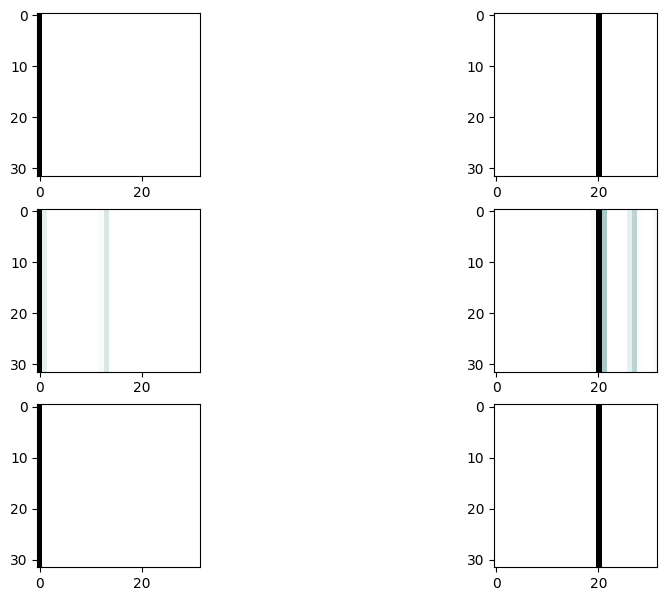

In [1078]:
ah = plot_attention(att, 0, 0, 3, False, size=(1080, 720));

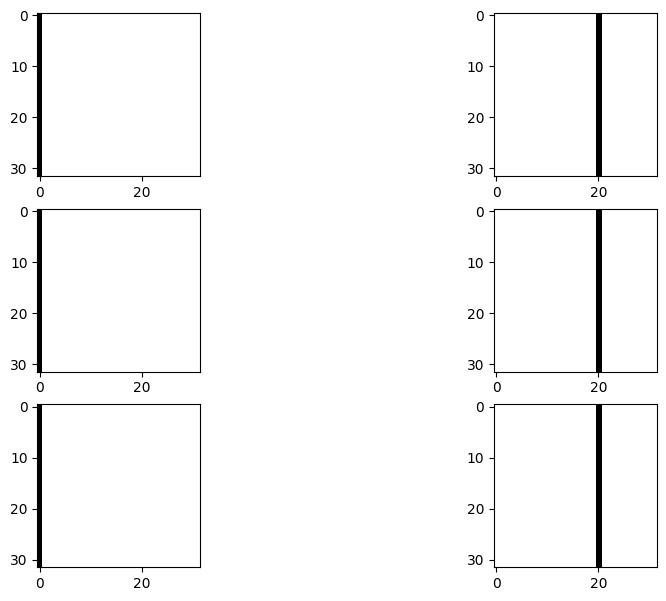

In [1079]:
plot_attention(att, 0, -1, 3, True, size=(1080, 720));

In [1080]:
def accuracy(prediction, target, error=0.01):
    prediction, target = prediction*divider, target*divider
    total = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    acc = (total.float().count_nonzero() / target.numel()).item()
    return np.round(acc, 4) * 100

In [1081]:
accuracy(transformer(eval_inp, single=False), eval_out)

0.0

In [1082]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    # transformer.train()
    transformer.requires_gradients(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs
    best_loss = F.mse_loss(transformer(train_inp, single=False), train_out,)
    best_epoch = -1
    save_state = transformer.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = transformer(train_inp, single=False)
            loss = F.mse_loss(test_actv, train_out)
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = transformer.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break

    transformer.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    transformer.requires_gradients(False)
    # transformer.eval()
    torch.cuda.empty_cache()
    return losses

training | loss= 1.1991e-04 | best= 1.2035e-04 | epoch=19995: progress=100% eta=0sec

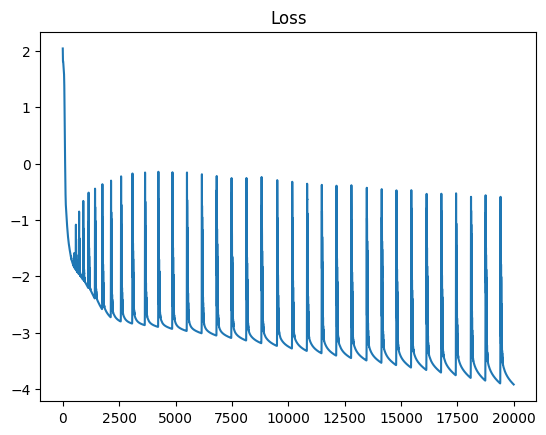

In [1083]:
train(20000, checkpoints=5);

In [1084]:
accuracy(transformer(eval_inp, single=False), eval_out), accuracy(transformer(train_inp, single=False), train_out)

(96.56, 90.31)

In [1085]:
outputs = transformer(eval_inp, verbose=1, get=True, single=True)
att, att_val = transformer.get_attention()


Transformer Input =>
tensor([[[[0.5930],
          [0.5950],
          [0.5969],
          ...,
          [0.6492],
          [0.6512],
          [0.6531]],

         [[0.1047],
          [0.1066],
          [0.1085],
          ...,
          [0.1609],
          [0.1628],
          [0.1647]],

         [[1.4186],
          [1.4205],
          [1.4225],
          ...,
          [1.4748],
          [1.4767],
          [1.4787]],

         ...,

         [[1.7616],
          [1.7636],
          [1.7655],
          ...,
          [1.8178],
          [1.8198],
          [1.8217]],

         [[0.9070],
          [0.9089],
          [0.9109],
          ...,
          [0.9632],
          [0.9651],
          [0.9671]],

         [[1.0988],
          [1.1008],
          [1.1027],
          ...,
          [1.1550],
          [1.1570],
          [1.1589]]]], device='cuda:0', dtype=torch.float64)
	dim = torch.Size([1, 10, 32, 1])

Embedded tensor =>
tensor([[[[-0.1072,  0.8855,  1.0308,  ..., -0.0

In [1086]:
for i, att_head in enumerate(eval_out[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[5379., 5405., 5432.,  ..., 6159., 6186., 6214.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[408., 419., 430.,  ..., 770., 784., 798.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[19845., 19886., 19926.,  ..., 21035., 21076., 21117.]],
       device='cuda:0', dtype=torch.float64)


In [1087]:
for i, att_head in enumerate(outputs[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 1])
tensor([[6215.]], device='cuda:0', dtype=torch.float64)
Record 2: torch.Size([1, 1])
tensor([[801.]], device='cuda:0', dtype=torch.float64)
Record 3: torch.Size([1, 1])
tensor([[21030.]], device='cuda:0', dtype=torch.float64)


In [1088]:
for i, att_head in enumerate(eval_inp[0, :3]):
    att_head = att_head.mT
    # att_head = normalize(att_head)
    print(f"Record {i+1}: {att_head.shape}")
    # print(att_head)
    # plt.imshow(att_head.float().cpu(), cmap='binary')
    print(torch.round(att_head*divider))
    plt.show()

Record 1: torch.Size([1, 32])
tensor([[612., 614., 616.,  ..., 670., 672., 674.]], device='cuda:0',
       dtype=torch.float64)
Record 2: torch.Size([1, 32])
tensor([[108., 110., 112.,  ..., 166., 168., 170.]], device='cuda:0',
       dtype=torch.float64)
Record 3: torch.Size([1, 32])
tensor([[1464., 1466., 1468.,  ..., 1522., 1524., 1526.]], device='cuda:0',
       dtype=torch.float64)


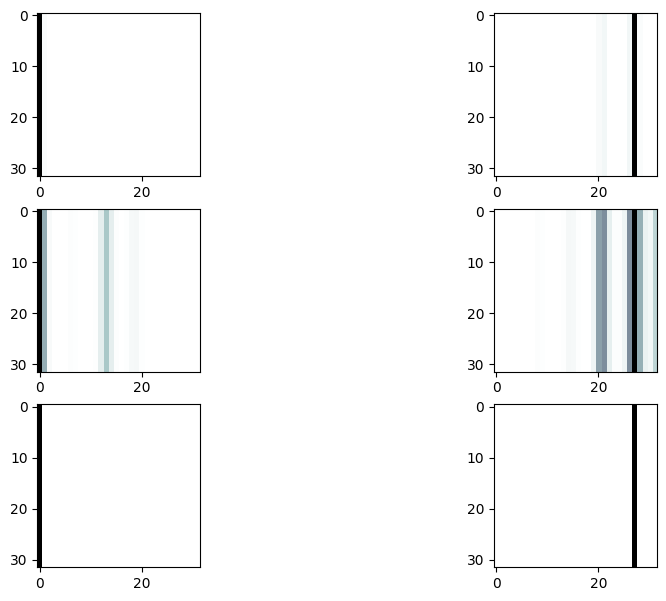

In [1089]:
plot_attention(att, 0, 0, 3, False, size=(1080, 720));

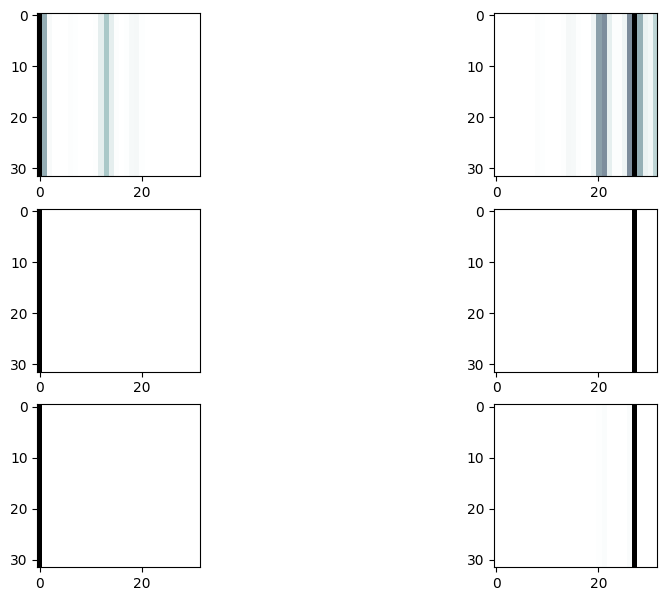

In [1090]:
plot_attention(att, 0, -1, 3, True, size=(1080, 720));

tensor([[ 0,  1,  2,  ...,  7,  8,  9],
        [10, 11, 12,  ..., 17, 18, 19],
        [20, 21, 22,  ..., 27, 28, 29],
        ...,
        [70, 71, 72,  ..., 77, 78, 79],
        [80, 81, 82,  ..., 87, 88, 89],
        [90, 91, 92,  ..., 97, 98, 99]])

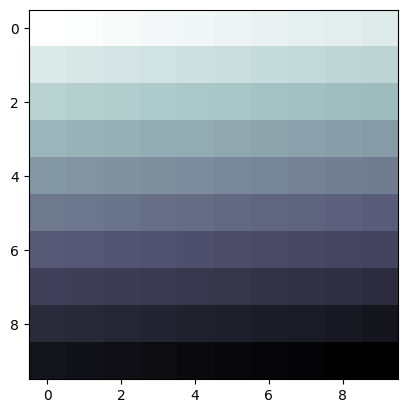

In [1091]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)